In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Проверяем формат столбцов

In [18]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сразу переведем столбец "Дата" в правильный формат

Сгруппируйте данные по дате, посчитайте количество продаж

In [20]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [21]:
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

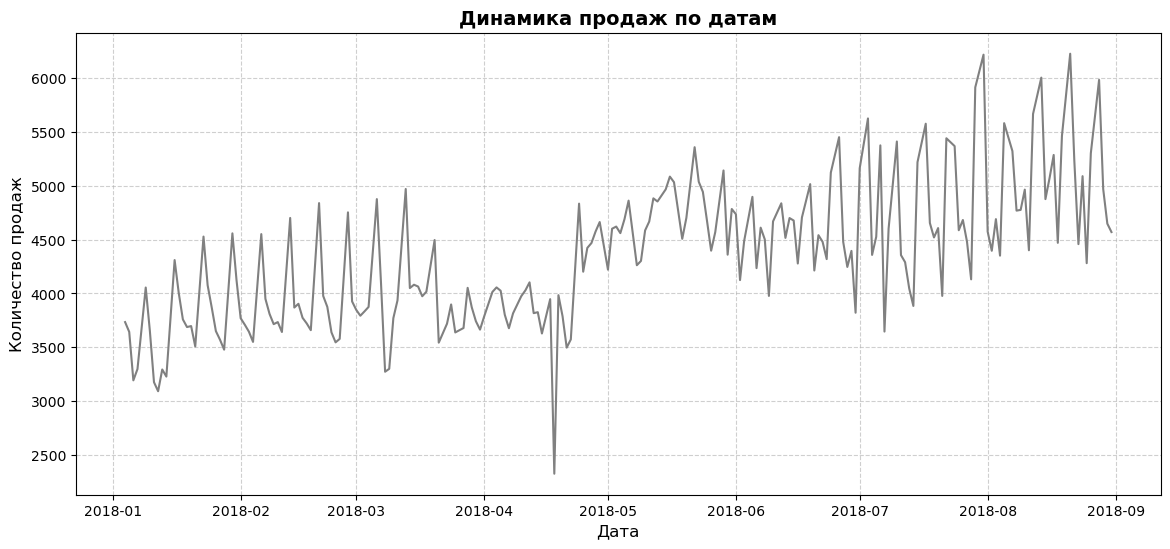

In [24]:
plt.figure(figsize=(14, 6))
plt.plot(grouped_df['Дата'], grouped_df['Количество'], color='gray', linewidth=1.5)

plt.title('Динамика продаж по датам', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество продаж', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

Тренд: На протяжении рассматриваемого периода (с января по август 2018 года) наблюдается устойчивый восходящий тренд. Общие объемы продаж постепенно растут: если в начале года показатели держались в диапазоне 3200–3700 единиц, то к концу лета они увеличились до уровня 4500–6000 единиц.

Цикличность: На графике четко прослеживаются регулярные колебания (пики и спады), которые повторяются с равными интервалами. Это указывает на цикличный характер спроса (например, изменение покупательской или операционной активности в течение календарной недели).

Волатильность: Амплитуда колебаний неоднородна. Во второй половине периода (в июле и августе) разброс между минимальными и максимальными значениями становится значительно шире, чем в первые месяцы года.

Аномалии (выбросы):
Зафиксирован резкий аномальный спад в конце апреля 2018 года, когда объем продаж упал ниже отметки в 2500 единиц.

Максимальные пиковые значения продаж приходятся на август 2018 года, где показатели превышают 6000 единиц.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [27]:
max_outlier_index = df['Количество'].idxmax()
outlier_row = df.loc[[max_outlier_index]]
outlier_row

,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [32]:
mask = (
    (df['Склад'] == 3) & 
    (df['Дата'].dt.month.isin([6, 7, 8])) & 
    (df['Дата'].dt.day_name() == 'Wednesday')
)

filtered_df = df[mask]

top_product = (
    filtered_df.groupby('Номенклатура')['Количество']
    .sum()
    .idxmax()
)

print(f"Топовый товар: {top_product}")

Топовый товар: product_1


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [108]:
weather = pd.read_csv('whether.csv',sep=';',skiprows=6,index_col = False)
weather.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,01.10.2018 23:00,7.2,733.6,765.2,0.2,90.0,"Ветер, дующий с северо-востока",2,NaN,NaN,...,NaN,NaN,NaN,5.7,Следы осадков,12.0,NaN,NaN,NaN,NaN
1,01.10.2018 20:00,8.5,733.4,764.9,0.7,90.0,"Ветер, дующий с севера",2,NaN,NaN,...,NaN,NaN,NaN,7.0,Следы осадков,12.0,NaN,NaN,NaN,NaN
2,01.10.2018 17:00,13.9,732.7,763.5,0.3,59.0,"Ветер, дующий с северо-северо-востока",1,NaN,NaN,...,NaN,NaN,10.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN
3,01.10.2018 14:00,15.8,732.4,763.0,0.2,51.0,"Ветер, дующий с западо-северо-запада",2,NaN,NaN,...,NaN,NaN,10.0,5.7,NaN,NaN,NaN,NaN,NaN,NaN
4,01.10.2018 11:00,17.8,732.2,762.7,-0.1,42.0,"Ветер, дующий с юго-запада",2,NaN,NaN,...,"Высококучевые просвечивающие, расположенные на...","Перистых, перисто-кучевых или перисто-слоистых...",10.0,4.5,NaN,NaN,NaN,NaN,NaN,NaN


In [110]:
# Извлекаем дату и среднюю T за день
weather['Дата'] = pd.to_datetime(weather['Местное время в Астане'], dayfirst=True).dt.normalize()
daily_temp = weather.groupby('Дата')['T'].mean().reset_index()

daily_temp.head()

,Дата,T
0,2018-01-01,-9.4625
1,2018-01-02,-9.5125
2,2018-01-03,-11.4625
3,2018-01-04,-14.0750
4,2018-01-05,-16.8625


In [111]:
# Объединяем grouped_df и daily_temp по дате
merged_df = pd.merge(grouped_df, daily_temp, on='Дата', how='inner')
merged_df.head()

,Дата,Количество,T
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500


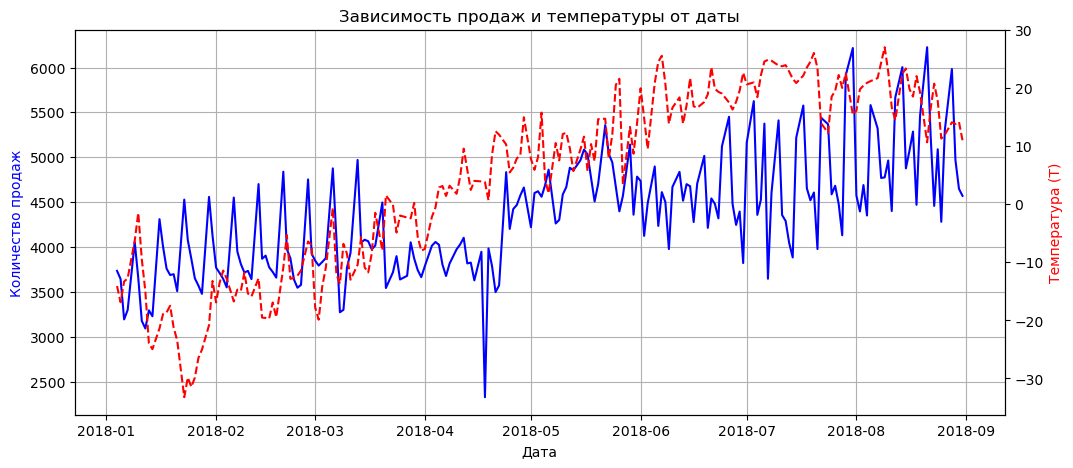

In [126]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Ось слева для Продаж
ax1.plot(merged_df['Дата'], merged_df.iloc[:, 1], color='blue', label='Продажи')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж', color='blue')
ax1.grid(True)

# Ось справа для Температуры T
ax2 = ax1.twinx()
ax2.plot(merged_df['Дата'], merged_df['T'], color='red', linestyle='--', label='T')
ax2.set_ylabel('Температура (T)', color='red')

plt.title('Зависимость продаж и температуры от даты')
plt.show()

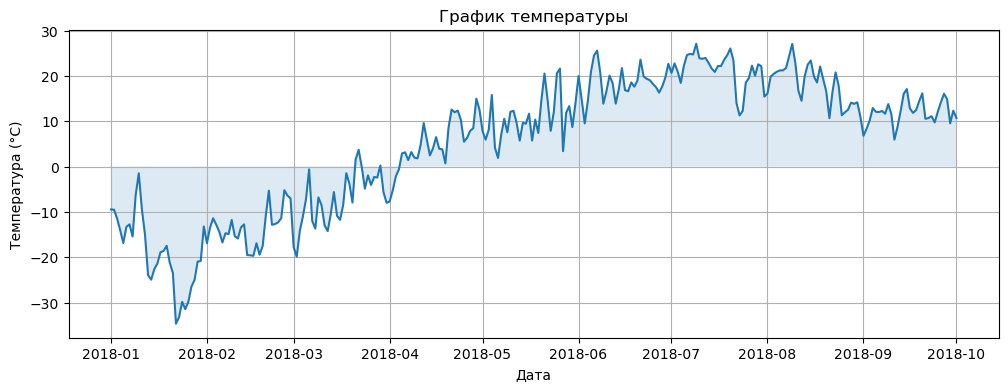

In [130]:
plt.figure(figsize=(12, 4))
plt.plot(daily_temp['Дата'], daily_temp['T'],linewidth=1.5, label='Температура (T)')
plt.fill_between(daily_temp['Дата'], daily_temp['T'], alpha=0.15)

plt.title('График температуры')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.grid(True)
plt.show()